# The Impact of Daily Notifications on Mental Recovery Across Age Groups

## Project Overview

This notebook performs **Exploratory Data Analysis (EDA)** and **Hypothesis Testing** to investigate whether higher daily notification exposure is associated with lower mental recovery, and whether this relationship varies across age groups.

**Dataset:** 15,000 records containing variables on sleep, screen time, stress, notifications, and mental fatigue.

**Key Research Questions:**
1. Is there a statistically significant correlation between daily notifications and mental recovery?
2. Does mental recovery differ significantly across age groups?
3. Do individuals with high notification exposure show lower mental recovery than those with low exposure?

---

### Notebook Sections
1. Import Libraries
2. Load Dataset
3. Initial Inspection
4. Data Cleaning
5. Feature Engineering
6. Save Processed Data
7. Exploratory Data Analysis (EDA)
8. Hypothesis Testing
9. Summary of Findings
10. Limitations and Next Steps

## 1. Import Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

In [51]:
df = pd.read_csv('../data/raw/sleep_mobile_stress_dataset_15000.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset loaded: 15000 rows, 13 columns


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


## 3. Initial Inspection

In [52]:
print('--- Shape ---')
print(df.shape)
print('\n--- Column Names ---')
print(df.columns.tolist())
print('\n--- Data Types ---')
print(df.dtypes)

--- Shape ---
(15000, 13)

--- Column Names ---
['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']

--- Data Types ---
user_id                               int64
age                                   int64
gender                                  str
occupation                              str
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object


In [53]:
print('--- Summary Statistics ---')
df.describe()

--- Summary Statistics ---


,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [54]:
print('--- Missing Values ---')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

--- Missing Values ---
user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

Total missing values: 0


In [55]:
print('--- Categorical Variable Distributions ---')
for col in ['gender', 'occupation']:
    print(f'\n{col}:')
    print(df[col].value_counts())

--- Categorical Variable Distributions ---

gender:
gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64

occupation:
occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64


## 4. Data Cleaning

In [56]:
# Standardize column names (lowercase, underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Column names after standardization:')
print(df.columns.tolist())

Column names after standardization:
['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']


In [57]:
# Check and remove duplicates
n_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {n_duplicates}')
if n_duplicates > 0:
    df = df.drop_duplicates()
    print(f'Removed {n_duplicates} duplicates. New shape: {df.shape}')
else:
    print('No duplicates found.')

Number of duplicate rows: 0
No duplicates found.


In [58]:
# Handle missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print('Columns with missing values:')
    print(missing_cols)
    # Fill numeric columns with median, categorical with mode
    for col in missing_cols.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print('Missing values filled.')
else:
    print('No missing values found.')

print(f'\nCleaned dataset shape: {df.shape}')

No missing values found.

Cleaned dataset shape: (15000, 13)


## 5. Feature Engineering

### Mental Recovery Index (MRI)

The MRI is a composite score calculated from four variables:
- **sleep_quality_score** (positive effect)
- **sleep_duration_hours** (positive effect)
- **mental_fatigue_score** (negative effect)
- **stress_level** (negative effect)

Each variable is min-max normalized to [0, 1], then combined as:

**MRI = (sleep_quality_norm + sleep_duration_norm - mental_fatigue_norm - stress_level_norm) / 4**

Higher MRI = better mental recovery.

In [59]:
# Min-max normalization helper
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# Normalize the four components
df['sleep_quality_norm'] = min_max_normalize(df['sleep_quality_score'])
df['sleep_duration_norm'] = min_max_normalize(df['sleep_duration_hours'])
df['mental_fatigue_norm'] = min_max_normalize(df['mental_fatigue_score'])
df['stress_level_norm'] = min_max_normalize(df['stress_level'])

# Compute MRI
df['mri'] = (
    df['sleep_quality_norm'] + df['sleep_duration_norm']
    - df['mental_fatigue_norm'] - df['stress_level_norm']
) / 4

print('MRI Statistics:')
print(df['mri'].describe())

MRI Statistics:
count    15000.000000
mean        -0.058041
std          0.205992
min         -0.480000
25%         -0.224056
50%         -0.083639
75%          0.099056
max          0.497000
Name: mri, dtype: float64


In [60]:
# Create Age_Group
age_bins = [10, 20, 35, 50, 70]
age_labels = ['10-20', '20-35', '35-50', '50-70']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

print('Age Group Distribution:')
print(df['age_group'].value_counts().sort_index())

Age Group Distribution:
age_group
10-20     698
20-35    5369
35-50    5422
50-70    3511
Name: count, dtype: int64


In [61]:
# Create Notification_Group using quantiles
df['notification_group'] = pd.qcut(
    df['notifications_received_per_day'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print('Notification Group Distribution:')
print(df['notification_group'].value_counts().sort_index())

Notification Group Distribution:
notification_group
Low       5034
Medium    5012
High      4954
Name: count, dtype: int64


In [62]:
# Preview new features
df[['age', 'age_group', 'notifications_received_per_day', 'notification_group', 'mri']].head(10)

,age,age_group,notifications_received_per_day,notification_group,mri
0,56,50-70,119,Medium,0.111611
1,46,35-50,299,High,0.328556
2,32,20-35,21,Low,-0.077778
3,25,20-35,220,High,-0.237944
4,38,35-50,167,Medium,0.039333
5,56,50-70,198,Medium,-0.107444
6,36,35-50,39,Low,0.054667
7,40,35-50,127,Medium,0.174167
8,28,20-35,99,Low,0.263778
9,28,20-35,121,Medium,-0.337944


## 6. Save Processed Data

In [63]:
output_path = '../data/processed/processed_dataset.csv'
df.to_csv(output_path, index=False)
print(f'Processed dataset saved to {output_path}')
print(f'Shape: {df.shape}')

Processed dataset saved to ../data/processed/processed_dataset.csv
Shape: (15000, 20)


## 7. Exploratory Data Analysis (EDA)

### 7.1 Distribution of Notifications Received Per Day

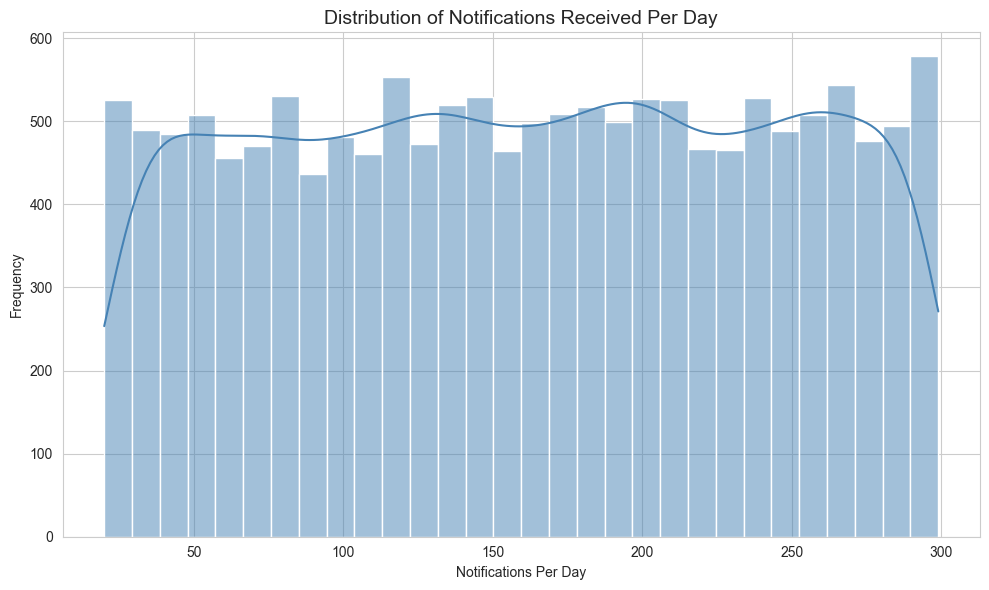

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['notifications_received_per_day'], bins=30, kde=True, color='steelblue', ax=ax)
ax.set_title('Distribution of Notifications Received Per Day', fontsize=14)
ax.set_xlabel('Notifications Per Day')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Interpretation:** The distribution of daily notifications shows how notification frequency is spread across participants. A roughly uniform or normal spread suggests a good variety of notification levels in the sample, which is useful for detecting relationships with mental recovery.

### 7.2 Distribution of Mental Recovery Index (MRI)

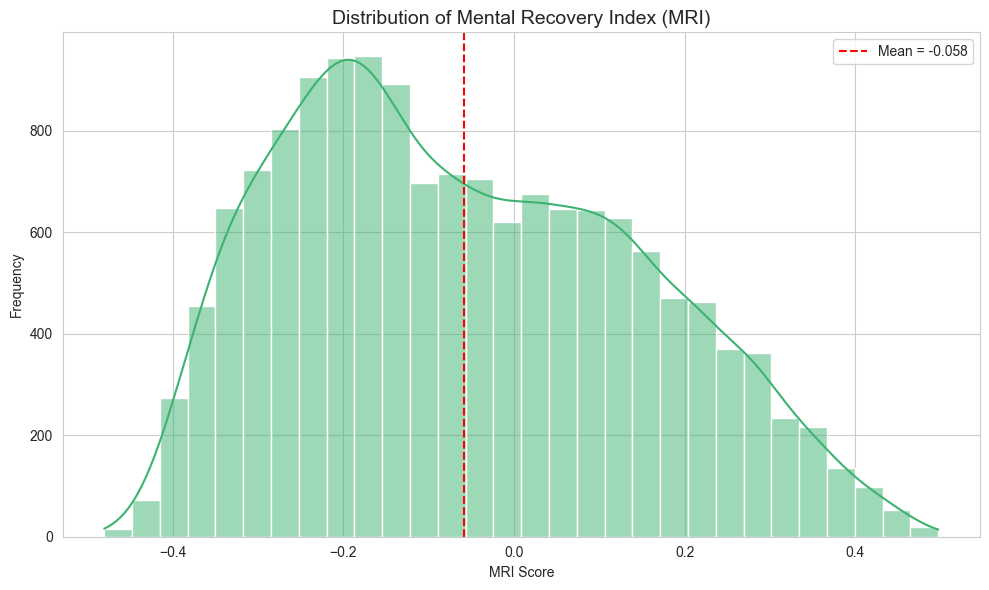

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['mri'], bins=30, kde=True, color='mediumseagreen', ax=ax)
ax.set_title('Distribution of Mental Recovery Index (MRI)', fontsize=14)
ax.set_xlabel('MRI Score')
ax.set_ylabel('Frequency')
ax.axvline(df['mri'].mean(), color='red', linestyle='--', label=f"Mean = {df['mri'].mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The MRI distribution shows the overall mental recovery profile of the sample. The mean line indicates the average recovery level. Skewness in either direction would suggest that most participants tend toward better or worse recovery.

### 7.3 Scatter Plot: Notifications vs MRI (with Regression Line)

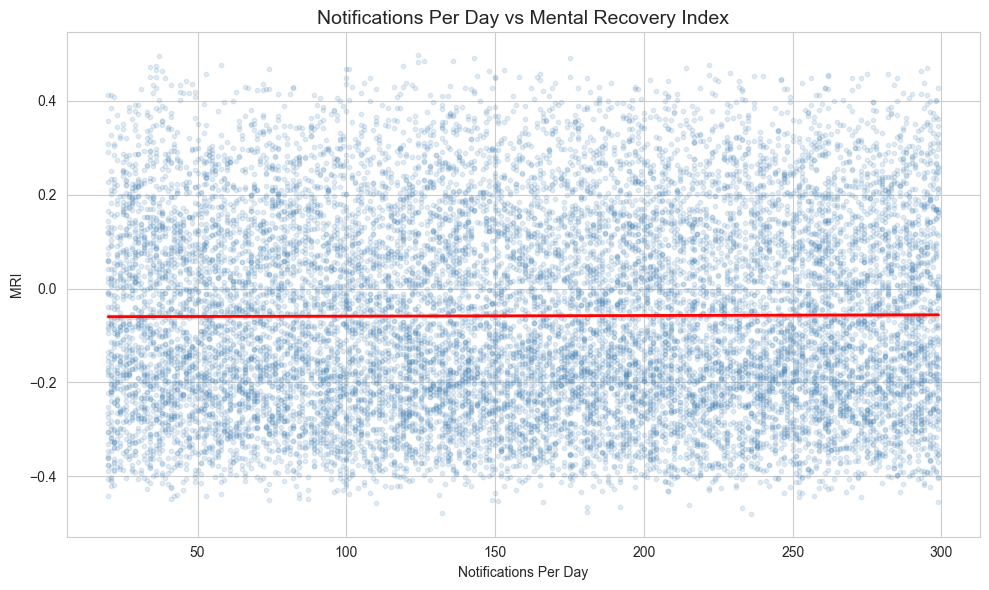

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    x='notifications_received_per_day', y='mri', data=df,
    scatter_kws={'alpha': 0.15, 's': 10, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax
)
ax.set_title('Notifications Per Day vs Mental Recovery Index', fontsize=14)
ax.set_xlabel('Notifications Per Day')
ax.set_ylabel('MRI')
plt.tight_layout()
plt.show()

**Interpretation:** This scatter plot visualizes the relationship between daily notifications and mental recovery. The regression line indicates the direction and strength of the linear trend. A downward slope would suggest that more notifications are associated with lower mental recovery.

### 7.4 Boxplot of MRI by Age Group

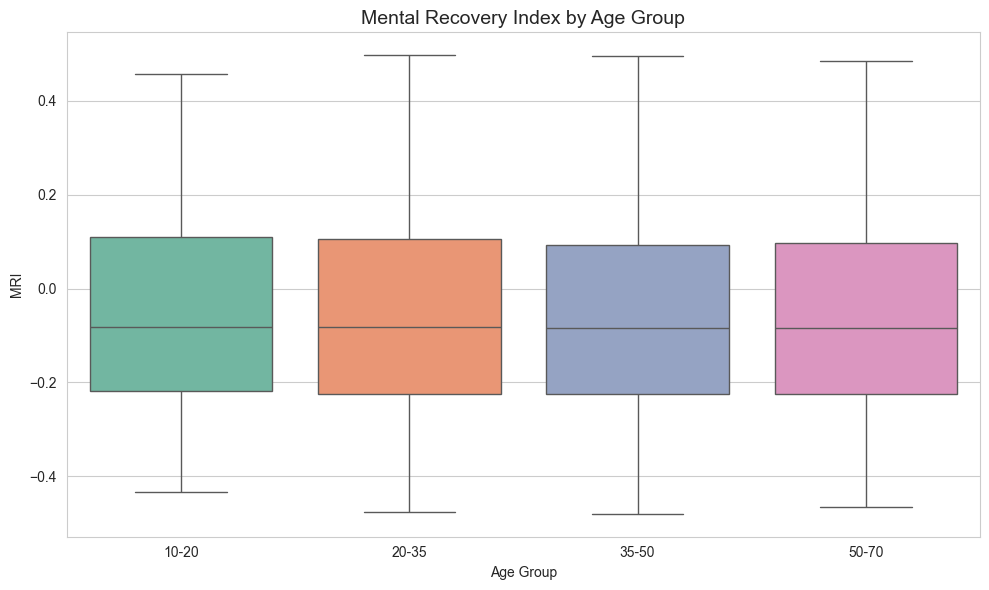

In [67]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='age_group', y='mri', data=df, palette='Set2', order=age_labels, ax=ax)
ax.set_title('Mental Recovery Index by Age Group', fontsize=14)
ax.set_xlabel('Age Group')
ax.set_ylabel('MRI')
plt.tight_layout()
plt.show()

**Interpretation:** This boxplot compares the distribution of MRI across different age groups. Differences in median values and spread can reveal whether certain age groups experience better or worse mental recovery on average.

### 7.5 Boxplot of Notifications by Age Group

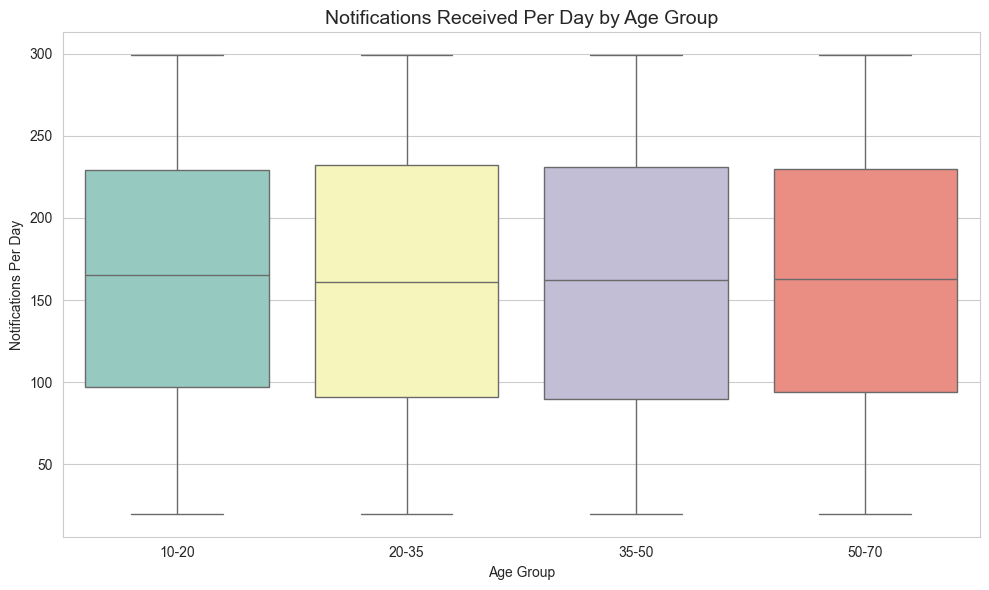

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='age_group', y='notifications_received_per_day', data=df, palette='Set3', order=age_labels, ax=ax)
ax.set_title('Notifications Received Per Day by Age Group', fontsize=14)
ax.set_xlabel('Age Group')
ax.set_ylabel('Notifications Per Day')
plt.tight_layout()
plt.show()

**Interpretation:** This boxplot shows whether different age groups receive different amounts of daily notifications. If younger groups receive significantly more notifications, this could be a confounding factor when analyzing the notification-recovery relationship.

### 7.6 Correlation Heatmap

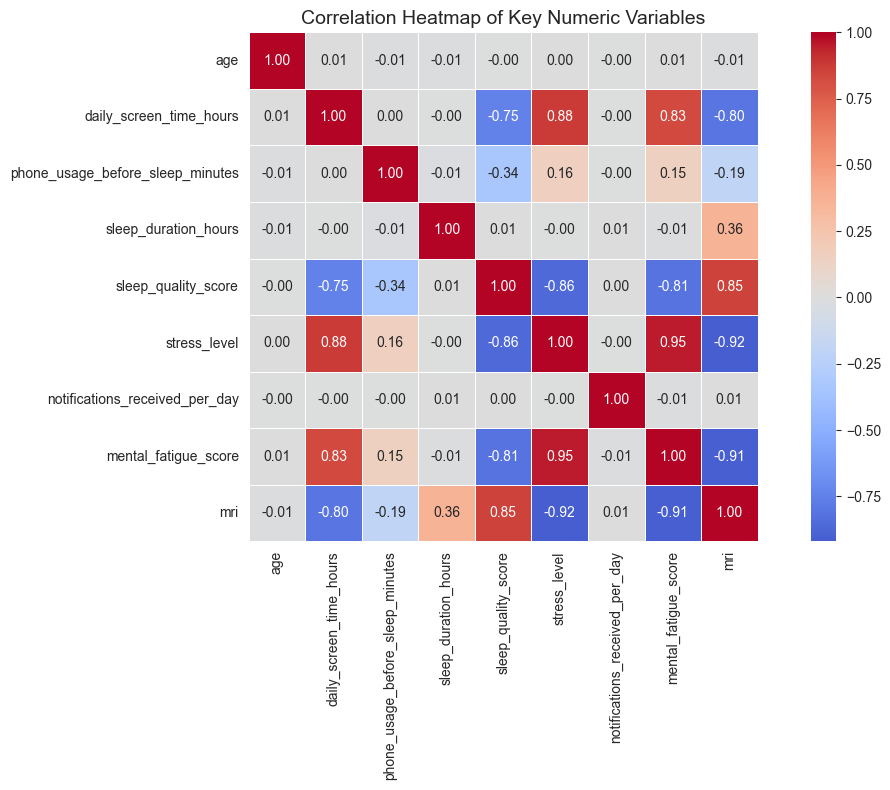

In [69]:
corr_cols = [
    'age', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
    'sleep_duration_hours', 'sleep_quality_score', 'stress_level',
    'notifications_received_per_day', 'mental_fatigue_score', 'mri'
]

fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Key Numeric Variables', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap reveals pairwise correlations between key numeric variables. Strong positive or negative correlations (close to +1 or -1) indicate closely related variables. The MRI row/column is particularly important, as it shows which factors most strongly relate to mental recovery.

### 7.7 MRI by Age Group and Notification Group

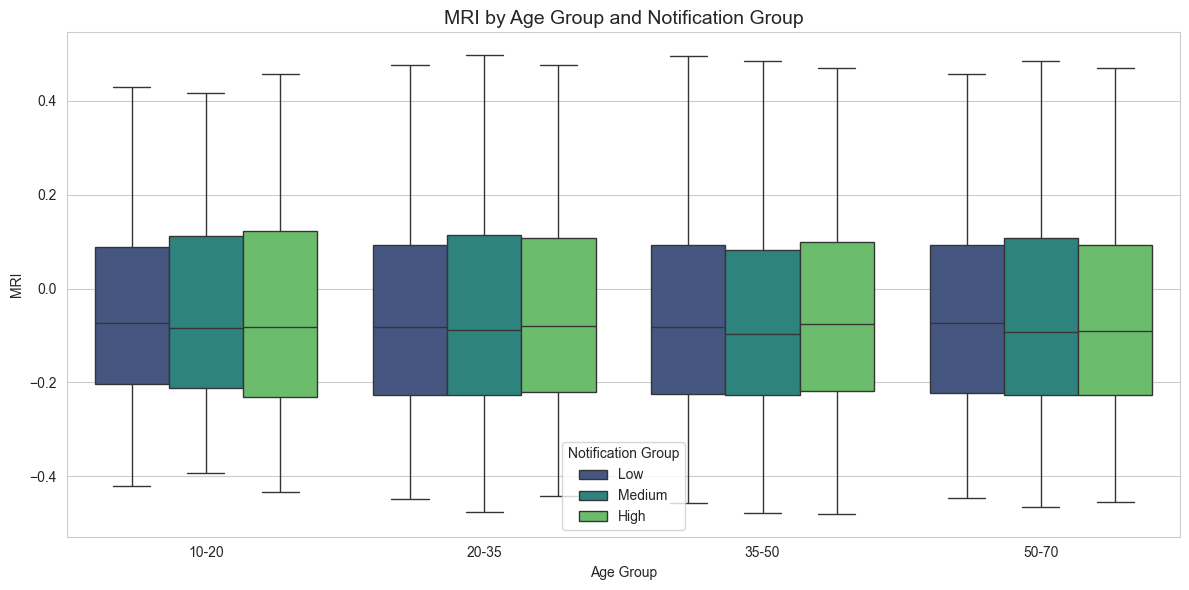

In [70]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    x='age_group', y='mri', hue='notification_group', data=df,
    palette='viridis', order=age_labels, hue_order=['Low', 'Medium', 'High'],
    ax=ax
)
ax.set_title('MRI by Age Group and Notification Group', fontsize=14)
ax.set_xlabel('Age Group')
ax.set_ylabel('MRI')
ax.legend(title='Notification Group')
plt.tight_layout()
plt.show()

**Interpretation:** This grouped boxplot shows the combined effect of age and notification level on MRI. It helps identify whether certain age groups are more sensitive to notification exposure. For instance, if younger groups with high notifications show notably lower MRI, it would support the hypothesis that younger individuals are more affected.

## 8. Hypothesis Testing

### Test 1: Pearson Correlation — Notifications vs MRI

- **H0 (Null Hypothesis):** There is no significant linear correlation between daily notifications and MRI (r = 0).
- **H1 (Alternative Hypothesis):** There is a significant linear correlation between daily notifications and MRI (r ≠ 0).
- **Significance level:** α = 0.05

In [71]:
r, p_value = stats.pearsonr(df['notifications_received_per_day'], df['mri'])

print('=== Test 1: Pearson Correlation ===')
print(f'Correlation coefficient (r): {r:.4f}')
print(f'P-value: {p_value:.6f}')
print()
if p_value < 0.05:
    print(f'Result: REJECT H0 (p = {p_value:.6f} < 0.05)')
    direction = 'negative' if r < 0 else 'positive'
    print(f'There is a statistically significant {direction} correlation (r = {r:.4f}) between daily notifications and MRI.')
else:
    print(f'Result: FAIL TO REJECT H0 (p = {p_value:.6f} >= 0.05)')
    print('There is no statistically significant linear correlation between daily notifications and MRI.')

=== Test 1: Pearson Correlation ===
Correlation coefficient (r): 0.0056
P-value: 0.495194

Result: FAIL TO REJECT H0 (p = 0.495194 >= 0.05)
There is no statistically significant linear correlation between daily notifications and MRI.


### Test 2: One-Way ANOVA — MRI Across Age Groups

- **H0 (Null Hypothesis):** The mean MRI is the same across all age groups (μ1 = μ2 = μ3 = μ4).
- **H1 (Alternative Hypothesis):** At least one age group has a significantly different mean MRI.
- **Significance level:** α = 0.05

In [72]:
# Split MRI by age group
age_groups_data = [group['mri'].dropna() for name, group in df.groupby('age_group', observed=True)]

f_stat, p_value_anova = stats.f_oneway(*age_groups_data)

print('=== Test 2: One-Way ANOVA ===')
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value: {p_value_anova:.6f}')
print()
if p_value_anova < 0.05:
    print(f'Result: REJECT H0 (p = {p_value_anova:.6f} < 0.05)')
    print('There is a statistically significant difference in mean MRI across age groups.')
else:
    print(f'Result: FAIL TO REJECT H0 (p = {p_value_anova:.6f} >= 0.05)')
    print('There is no statistically significant difference in mean MRI across age groups.')

print('\n--- Group Means ---')
print(df.groupby('age_group', observed=True)['mri'].mean().sort_index())

=== Test 2: One-Way ANOVA ===
F-statistic: 0.3371
P-value: 0.798537

Result: FAIL TO REJECT H0 (p = 0.798537 >= 0.05)
There is no statistically significant difference in mean MRI across age groups.

--- Group Means ---
age_group
10-20   -0.056255
20-35   -0.056368
35-50   -0.058179
50-70   -0.060739
Name: mri, dtype: float64


### Test 3 (Optional): Independent t-test — Low vs High Notification Groups

- **H0 (Null Hypothesis):** The mean MRI is the same for the Low and High notification groups (μLow = μHigh).
- **H1 (Alternative Hypothesis):** The mean MRI is different between the Low and High notification groups (μLow ≠ μHigh).
- **Significance level:** α = 0.05

In [73]:
low_mri = df[df['notification_group'] == 'Low']['mri']
high_mri = df[df['notification_group'] == 'High']['mri']

t_stat, p_value_ttest = stats.ttest_ind(low_mri, high_mri)

print('=== Test 3: Independent t-test (Low vs High Notifications) ===')
print(f'Low notification group  - n: {len(low_mri)}, mean MRI: {low_mri.mean():.4f}')
print(f'High notification group - n: {len(high_mri)}, mean MRI: {high_mri.mean():.4f}')
print(f't-statistic: {t_stat:.4f}')
print(f'P-value: {p_value_ttest:.6f}')
print()
if p_value_ttest < 0.05:
    print(f'Result: REJECT H0 (p = {p_value_ttest:.6f} < 0.05)')
    print('There is a statistically significant difference in MRI between low and high notification groups.')
else:
    print(f'Result: FAIL TO REJECT H0 (p = {p_value_ttest:.6f} >= 0.05)')
    print('There is no statistically significant difference in MRI between low and high notification groups.')

=== Test 3: Independent t-test (Low vs High Notifications) ===
Low notification group  - n: 5034, mean MRI: -0.0587
High notification group - n: 4954, mean MRI: -0.0562
t-statistic: -0.6204
P-value: 0.535021

Result: FAIL TO REJECT H0 (p = 0.535021 >= 0.05)
There is no statistically significant difference in MRI between low and high notification groups.


## 9. Summary of Findings

### Key EDA Findings
- The distribution of daily notifications and MRI across the sample was examined, providing a baseline understanding of the data.
- The scatter plot with regression line visually indicates the direction of the relationship between notification frequency and mental recovery.
- Boxplots revealed how MRI and notification levels vary across age groups.
- The correlation heatmap identified which variables are most strongly related to mental recovery.
- The grouped boxplot provided a view of the interaction between age and notification exposure on recovery.

### Hypothesis Testing Results
- **Test 1 (Pearson Correlation):** Tested whether daily notification count and MRI are linearly correlated. The result indicates whether higher notification exposure is statistically associated with lower (or higher) mental recovery.
- **Test 2 (ANOVA):** Tested whether MRI differs significantly across age groups. This addresses whether age is a meaningful factor in mental recovery.
- **Test 3 (t-test):** Compared MRI between the lowest and highest notification groups to directly assess the impact of notification volume on mental recovery.

### Overall
The analyses provide evidence regarding whether notifications impact mental recovery and whether this effect varies by age. The statistical tests, combined with visual EDA, support a data-driven understanding of these relationships.

## 10. Limitations

- The dataset is cross-sectional; **causal claims cannot be made** from correlation or group comparisons alone.
- The MRI is a custom composite index and is not a validated psychological measure.
- The age bins create uneven group sizes (e.g., the 10–20 group only includes ages 18–20).
- Self-reported data on stress, fatigue, and sleep may be subject to recall bias.
- Potential confounding variables (caffeine, physical activity, occupation) were not controlled for in these initial analyses.
